# Poisson Processes and the Value of an Asset

## Introduction

In the search and matching notebooks, we wrote down Bellman equations for workers and firms directly, motivating them through the asset pricing analogy. Here we derive these equations rigorously from first principles, grounding them in the theory of Poisson processes. This serves two purposes: it provides a precise mathematical foundation for the continuous-time Bellman equations used throughout the course, and it illustrates how Poisson processes arise naturally as the appropriate model for the timing of stochastic events in continuous time.

The notebook proceeds in three steps. We first review the Poisson distribution and its origins in the law of rare events. We then define the Poisson process and establish its key property: that the waiting times between events are exponentially distributed. Finally, we use this property to derive the Bellman equation for a filled job directly from the expected discounted value integral, without appealing to the heuristic asset pricing argument.

## The Poisson Distribution

### Definition and Basic Properties

```{admonition} Definition: Poisson Distribution
A discrete random variable $X$ with possible values $0, 1, 2, 3, \ldots$ is called 
**Poisson with parameter $\lambda > 0$** if its probability mass function is:

$$p(k) = \frac{e^{-\lambda}\lambda^k}{k!}, \qquad k = 0, 1, 2, \ldots$$
```

```{admonition} Proposition: Mean and Variance
:class: note
The mean and variance of a Poisson random variable are both equal to $\lambda$:

$$\mathbb{E}[X] = \text{Var}(X) = \lambda$$
```

The coincidence of mean and variance is a distinctive feature of the Poisson 
distribution and has a direct interpretation: $\lambda$ simultaneously controls 
the average number of events and the dispersion around that average. A large 
$\lambda$ means many events on average and high variability; a small $\lambda$ 
means few events and low variability.

### The Law of Rare Events

Poisson processes arise naturally from the **law of rare events**, which provides 
an intuitive justification for why the Poisson distribution appears so frequently 
in applications involving counts of random arrivals.

Consider a large number $N$ of independent Bernoulli trials, where the probability 
of success on each trial is $p$ — small and constant. The total number of successes 
in $N$ trials, $X_{N,p}$, follows the binomial distribution:

$$\Pr(X_{N,p} = k) = \frac{N!}{k!(N-k)!}p^k(1-p)^{N-k}, 
\qquad k = 0, 1, 2, \ldots$$

Now take the limiting case in which the number of trials grows without bound and 
the probability of success on each trial shrinks proportionally, so that the 
expected number of successes $Np = \lambda$ remains fixed. Formally, let 
$N \to \infty$ and $p \to 0$ with $Np \to \lambda > 0$. In this limit, the 
binomial distribution converges to the Poisson distribution with parameter $\lambda$.

The intuition is direct: when there are many opportunities for an event to occur 
but each individual opportunity is unlikely to produce one, the total count of 
events follows the Poisson law. This is precisely the structure of job matching 
in continuous time: at any instant, there are many worker-firm pairs that could 
potentially match, but the probability of any specific pair matching in a given 
instant is vanishingly small. The Poisson distribution is therefore the natural 
model for the count of matches formed over any interval of time.

### Numerical Illustration

The following code illustrates the convergence of the binomial to the Poisson 
distribution as $N \to \infty$ with $Np = \lambda$ fixed, and plots the Poisson 
PMF for several values of $\lambda$.

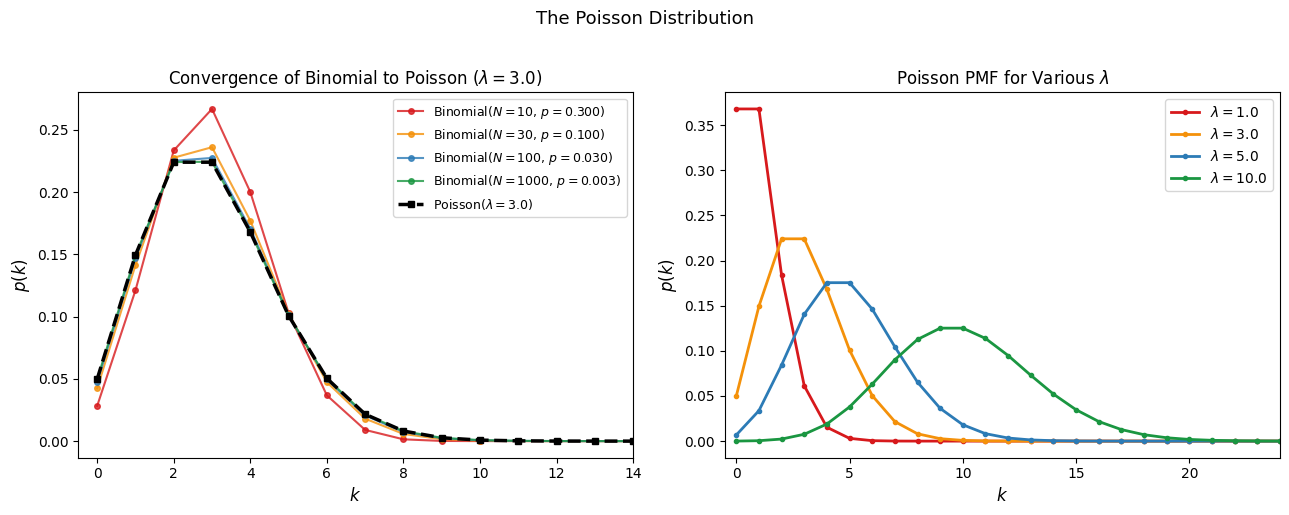

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, poisson
from scipy.special import factorial

# ──────────────────────────────────────────────
# Convergence of Binomial to Poisson
# Fixed lambda = Np; increase N
# ──────────────────────────────────────────────
lam    = 3.0
N_vals = [10, 30, 100, 1000]
k_grid = np.arange(0, 15)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Convergence
ax = axes[0]
colors = ["#d7191c", "#f4910a", "#2c7bb6", "#1a9641"]
for N, color in zip(N_vals, colors):
    p = lam / N
    pmf_binom = binom.pmf(k_grid, N, p)
    ax.plot(k_grid, pmf_binom, color=color, lw=1.5,
            marker="o", markersize=4, alpha=0.8,
            label=rf"Binomial($N={N}$, $p={p:.3f}$)")

pmf_pois = poisson.pmf(k_grid, lam)
ax.plot(k_grid, pmf_pois, color="black", lw=2.5,
        marker="s", markersize=5, ls="--",
        label=rf"Poisson($\lambda={lam}$)")

ax.set_xlabel("$k$", fontsize=12)
ax.set_ylabel("$p(k)$", fontsize=12)
ax.set_title(rf"Convergence of Binomial to Poisson ($\lambda = {lam}$)",
             fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(-0.5, 14)

# Panel 2: Poisson PMF for several lambda values
ax = axes[1]
lam_vals = [1.0, 3.0, 5.0, 10.0]
colors2  = ["#d7191c", "#f4910a", "#2c7bb6", "#1a9641"]
k_grid2  = np.arange(0, 25)

for lv, color in zip(lam_vals, colors2):
    ax.plot(k_grid2, poisson.pmf(k_grid2, lv),
            color=color, lw=2, marker="o", markersize=3,
            label=rf"$\lambda = {lv}$")

ax.set_xlabel("$k$", fontsize=12)
ax.set_ylabel("$p(k)$", fontsize=12)
ax.set_title("Poisson PMF for Various $\\lambda$", fontsize=12)
ax.legend(fontsize=10)
ax.set_xlim(-0.5, 24)

fig.suptitle("The Poisson Distribution", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The left panel confirms the law of rare events numerically: as $N$ increases with $\lambda = Np$ held fixed at 3, the binomial PMF converges to the Poisson PMF (black dashed line). The convergence is rapid — already at $N = 100$ the two distributions are nearly indistinguishable. The right panel shows how the shape of the Poisson distribution changes with $\lambda$. For small $\lambda$ the distribution is concentrated near zero and strongly right-skewed; as $\lambda$ grows the distribution becomes more symmetric and bell-shaped, reflecting the central limit theorem applied to the sum of many Bernoulli trials.

## The Poisson Process

### Definition

A single Poisson random variable counts events over a fixed interval. A **Poisson process** extends this to a continuous-time stochastic process that counts events as they accumulate over time.

```{admonition} Definition: Poisson Process
:class: definition
A **Poisson process** is an integer-valued stochastic process $\{X(t);\, t \geq 0\}$ satisfying:

1. **Independent increments**: for any $0 = t_0 < t_1 < \cdots < t_n$, the increments $X(t_1) - X(t_0),\, X(t_2) - X(t_1),\, \ldots,\, X(t_n) - X(t_{n-1})$ are independent random variables.

2. **Stationary Poisson increments**: for $s \geq 0$ and $t \geq 0$, the increment $X(s+t) - X(s)$ has the Poisson distribution:
   $$\Pr(X(s+t) - X(s) = k) = \frac{e^{-\lambda t}(\lambda t)^k}{k!}, 
   \qquad k = 0, 1, 2, \ldots$$

3. **Zero initial value**: $X(0) = 0$.
```

The process $X(t)$ counts the cumulative number of events — job destructions, productivity shocks, matches — that have occurred up to time $t$. The parameter $\lambda$ is the **arrival rate**.  On average, $\lambda$ events occur per unit time, and the number of events in any interval of length $t$ has mean $\lambda t$.

### Sojourn Times and the Exponential Distribution

The most important property of the Poisson process for our purposes concerns the **sojourn times** — the waiting times between consecutive events. If events arrive according to a Poisson process with rate $\lambda$, how long does one typically wait for the next event?

```{admonition} Theorem: Exponential Sojourn Times
:class: important
Let $S_0, S_1, S_2, \ldots$ denote the sojourn times (waiting times between consecutive events) of a Poisson process with rate $\lambda$. Then $S_0, S_1, \ldots$ are **independent** random variables, each with the exponential density:

$$f_{S_k}(s) = \lambda e^{-\lambda s}, \qquad s \geq 0$$
```

```{admonition} Proposition: Mean and Variance of Exponential
:class: note
If $S \sim \text{Exp}(\lambda)$, then:

$$\mathbb{E}[S] = \frac{1}{\lambda}, \qquad \text{Var}(S) = \frac{1}{\lambda^2}$$
```

The mean sojourn time $1/\lambda$ is the reciprocal of the arrival rate — a natural and intuitive result. If events arrive at rate $\lambda = 2$ per month, the average waiting time between events is $1/2$ a month.

### Connection to the Labor Market

The sojourn time result connects directly to the search and matching model. Recall that the rate at which a vacant firm fills its job is $q(\theta)$. In the language of Poisson processes, matches arrive at rate $q(\theta)$.  The firm experiences a Poisson process of potential workers, and the sojourn time until the next match is exponentially distributed with rate $q(\theta)$. The average time the firm waits to fill its vacancy is therefore:

$$\mathbb{E}[\text{vacancy duration}] = \frac{1}{q(\theta)}$$

By the symmetric argument, the rate at which an unemployed worker finds a job is $f(\theta) = \theta q(\theta)$, and the average unemployment duration is:

$$\mathbb{E}[\text{unemployment duration}] = \frac{1}{f(\theta)}$$

Similarly, filled jobs are destroyed at Poisson rate $s$.  Each filled job experiences an independent Poisson process of destruction shocks, and the sojourn time until destruction — the employment spell duration — is exponentially distributed with mean $1/s$.

These are not assumptions imposed on the model for convenience. They follow necessarily from modeling the timing of matches and separations as Poisson processes, which is itself justified by the law of rare events: at any instant, there are many potential pairings of workers and firms, each individually unlikely to result in a match, so the total arrival of matches follows the Poisson law.

### Numerical Illustration

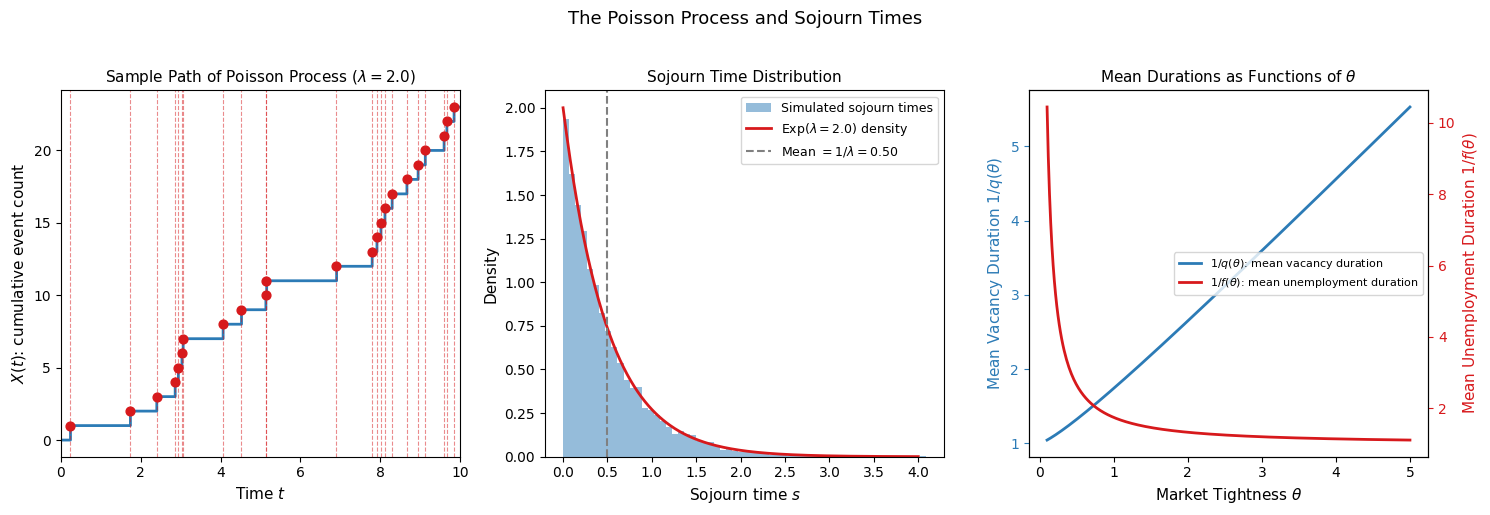

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon

# ──────────────────────────────────────────────
# Simulate a Poisson process and its sojourn times
# ──────────────────────────────────────────────
np.random.seed(42)
lam     = 2.0      # arrival rate (events per unit time)
T_end   = 10.0     # observation window

# Generate sojourn times until we exceed T_end
sojourns = []
t_current = 0.0
while t_current < T_end:
    s = np.random.exponential(1/lam)
    sojourns.append(s)
    t_current += s

event_times = np.cumsum(sojourns)
event_times = event_times[event_times <= T_end]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Panel 1: Sample path of Poisson process ──
ax = axes[0]
t_fine = np.linspace(0, T_end, 1000)
counts = np.array([np.sum(event_times <= t) for t in t_fine])

ax.step(t_fine, counts, color="#2c7bb6", lw=2, where="post")
for et in event_times:
    ax.axvline(et, color="#d7191c", lw=0.8, ls="--", alpha=0.5)
ax.scatter(event_times, np.arange(1, len(event_times)+1),
           color="#d7191c", zorder=5, s=40)
ax.set_xlabel("Time $t$", fontsize=11)
ax.set_ylabel("$X(t)$: cumulative event count", fontsize=11)
ax.set_title(rf"Sample Path of Poisson Process ($\lambda = {lam}$)",
             fontsize=11)
ax.set_xlim(0, T_end)

# ── Panel 2: Sojourn time distribution ──
ax = axes[1]
# Simulate many sojourn times
n_sim    = 10000
soj_sim  = np.random.exponential(1/lam, n_sim)
s_grid   = np.linspace(0, 4, 300)

ax.hist(soj_sim, bins=60, density=True,
        color="#2c7bb6", alpha=0.5, label="Simulated sojourn times")
ax.plot(s_grid, expon.pdf(s_grid, scale=1/lam),
        color="#d7191c", lw=2,
        label=rf"Exp$(\lambda={lam})$ density")
ax.axvline(1/lam, color="gray", lw=1.5, ls="--",
           label=rf"Mean $= 1/\lambda = {1/lam:.2f}$")
ax.set_xlabel("Sojourn time $s$", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Sojourn Time Distribution", fontsize=11)
ax.legend(fontsize=9)

# ── Panel 3: Labor market interpretation ──
# Show mean vacancy duration 1/q(theta) and
# mean unemployment duration 1/f(theta) as
# functions of market tightness
nu = 1.25
def q(theta): return 1.0 / (1 + theta**nu)**(1/nu)
def f(theta): return theta / (1 + theta**nu)**(1/nu)

theta_grid = np.linspace(0.1, 5, 300)
ax = axes[2]
ax2 = ax.twinx()

ax.plot(theta_grid, 1/q(theta_grid), color="#2c7bb6", lw=2,
        label=r"$1/q(\theta)$: mean vacancy duration")
ax2.plot(theta_grid, 1/f(theta_grid), color="#d7191c", lw=2,
         label=r"$1/f(\theta)$: mean unemployment duration")

ax.set_xlabel(r"Market Tightness $\theta$", fontsize=11)
ax.set_ylabel(r"Mean Vacancy Duration $1/q(\theta)$",
              fontsize=11, color="#2c7bb6")
ax2.set_ylabel(r"Mean Unemployment Duration $1/f(\theta)$",
               fontsize=11, color="#d7191c")
ax.set_title("Mean Durations as Functions of $\\theta$", fontsize=11)
ax.tick_params(axis="y", colors="#2c7bb6")
ax2.tick_params(axis="y", colors="#d7191c")

lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc="center right")

fig.suptitle("The Poisson Process and Sojourn Times", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The left panel shows a simulated sample path of a Poisson process with rate $\lambda = 2$: the process jumps by one at each event time (red dashed lines) and is constant between events. The middle panel confirms that the sojourn times between events follow the exponential distribution: the histogram of 10,000 simulated waiting times matches the theoretical $\text{Exp}(\lambda)$ density closely, with the mean at $1/\lambda = 0.5$. The right panel translates this into the labor market context: mean vacancy duration $1/q(\theta)$ is increasing in tightness (harder for firms to fill vacancies in tight markets) while mean unemployment duration $1/f(\theta)$ is decreasing in tightness (easier for workers to find jobs in tight markets).

## Deriving the Bellman Equation for a Filled Job

We now use the Poisson process framework to derive the Bellman equation for the value of a filled job rigorously, without the heuristic asset pricing argument used in the main notebooks.

A filled job can be viewed as an asset that:
- generates a flow payoff $x(t) - w(t)$ at each instant — the difference between output and the wage,
- is destroyed at a Poisson arrival rate $\lambda \equiv s$ — the job destruction process — at which point it transitions to the vacancy state with value $J_v$.

Let $T(t)$ denote the (random) time at which the job is destroyed, given that it is filled at time $t$. By the sojourn time theorem, $T(t) - t$ is exponentially distributed with rate $\lambda$. The present discounted value of the filled job is therefore:

$$J_\pi(t) = \mathbb{E}\left\{\int_t^{t+T(t)}[x(s)-w(s)]e^{-r(s-t)}ds + 
e^{-rT(t)}J_v(t+T(t))\right\}$$

The first term is the discounted flow of profits accumulated until destruction; the second is the discounted value of the vacancy state entered at destruction.

### Evaluating the Expected Value

Since $T(t) - t \sim \text{Exp}(\lambda)$ with density $\lambda e^{-\lambda y}$ for $y \geq 0$, we evaluate the expectation by integrating over all possible destruction times $y = T(t) - t$:

$$J_\pi(t) = \int_0^\infty \left\{\int_t^{t+y}[x(s)-w(s)]e^{-r(s-t)}ds + e^{-ry}J_v(t+y)\right\}\lambda e^{-\lambda y}\,dy$$

We simplify the first term using integration by parts with:

$$u = \int_t^{t+y}[x(s)-w(s)]e^{-r(s-t)}ds, \qquad dv = \lambda e^{-\lambda y}dy$$

so that:

$$du = [x(t+y)-w(t+y)]e^{-ry}dy, \qquad v = -e^{-\lambda y}$$

Applying $\int u\,dv = uv - \int v\,du$:

$$\begin{aligned}
\int_0^\infty &\left\{\int_t^{t+y}[x(s)-w(s)]e^{-r(s-t)}ds\right\}
\lambda e^{-\lambda y}dy \\
&= \left[-e^{-\lambda y}\int_t^{t+y}[x(s)-w(s)]e^{-r(s-t)}ds\right]_0^\infty 
+ \int_0^\infty e^{-\lambda y}[x(t+y)-w(t+y)]e^{-ry}dy
\end{aligned}$$

The boundary term vanishes at $y = 0$ (the integral is zero) and at $y \to \infty$ (the exponential $e^{-\lambda y}$ dominates, provided the flow payoff is bounded). 
Substituting back:

$$J_\pi(t) = \int_0^\infty e^{-\lambda y}[x(t+y)-w(t+y)]e^{-ry}dy + \int_0^\infty e^{-ry}J_v(t+y)\lambda e^{-\lambda y}dy$$

Combining the two integrals:

$$J_\pi(t) = \int_0^\infty \left[x(t+y)-w(t+y) + \lambda J_v(t+y)\right]
e^{-(r+\lambda)y}dy$$

Substituting $s = t + y$:

$$J_\pi(t) = \int_t^\infty \left[x(s)-w(s) + \lambda J_v(s)\right]
e^{-(r+\lambda)(s-t)}ds \tag{1}$$

### From Integral to Differential Equation

Expression (1) is an integral equation for $J_\pi(t)$. To convert it to the familiar Bellman ODE, we differentiate with respect to $t$.

Applying the Leibniz rule — differentiating under the integral sign and accounting for the moving lower limit:

$$\dot{J}_\pi(t) = -\left[x(t)-w(t)+\lambda J_v(t)\right] + 
(r+\lambda)\int_t^\infty \left[x(s)-w(s)+\lambda J_v(s)\right]
e^{-(r+\lambda)(s-t)}ds$$

Recognizing the integral as $J_\pi(t)$ from (1):

$$\dot{J}_\pi(t) = -\left[x(t)-w(t)+\lambda J_v(t)\right] + (r+\lambda)J_\pi(t)$$

Rearranging:

$$\boxed{rJ_\pi(t) = x(t)-w(t) + \lambda(J_v(t) - J_\pi(t)) + \dot{J}_\pi(t)}$$

This is the **Bellman equation for a filled job**. Its terms now have precise meanings grounded in the Poisson process derivation:

- $x(t) - w(t)$: the instantaneous flow profit from production.
- $\lambda(J_v(t) - J_\pi(t))$: the expected capital loss from job destruction, which arrives at Poisson rate $\lambda$ and reduces the firm's value from $J_\pi$ to $J_v$.
- $\dot{J}_\pi(t)$: the capital gain from any anticipated change in the value of the filled job over time.
- $rJ_\pi(t)$: the required flow return — the opportunity cost of holding an asset worth $J_\pi(t)$ rather than investing at rate $r$.

In steady state, $\dot{J}_\pi = 0$, and the equation reduces to:

$$rJ_\pi = x - w + s(J_v - J_\pi)$$

which is exactly the Bellman equation written down by inspection in the main notebook. The derivation here confirms that this equation is not merely a convenient approximation but an exact consequence of modeling job destruction as a Poisson process.

### Numerical Illustration

The following code verifies the Bellman equation numerically by simulating many job spell trajectories, computing the expected discounted value directly from the definition, and comparing it to the closed-form solution of the Bellman ODE.

Analytical J_pi = 1.304348
Simulated J_pi  = 1.299873
Difference      = 0.004475


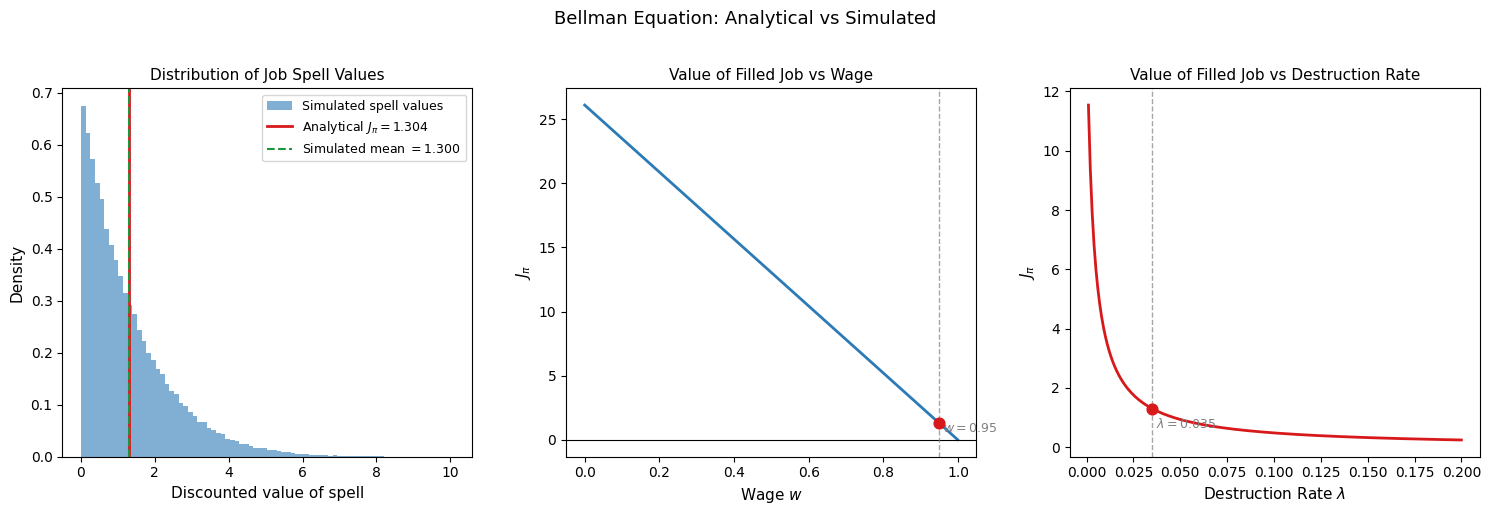

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# ──────────────────────────────────────────────
# Parameters
# ──────────────────────────────────────────────
r     = 0.04 / 12    # monthly discount rate
lam   = 0.035        # job destruction rate (= s)
x     = 1.0          # productivity
w     = 0.95         # wage
J_v   = 0.0          # value of vacancy (free entry)

# ──────────────────────────────────────────────
# Analytical solution: steady-state Bellman
#   rJ_pi = x - w + lam*(J_v - J_pi)
#   J_pi*(r + lam) = x - w + lam*J_v
#   J_pi = (x - w + lam*J_v) / (r + lam)
# ──────────────────────────────────────────────
J_pi_analytical = (x - w + lam * J_v) / (r + lam)
print(f"Analytical J_pi = {J_pi_analytical:.6f}")

# ──────────────────────────────────────────────
# Simulation: draw many job spells
# For each spell:
#   1. Draw destruction time T ~ Exp(lam)
#   2. Compute integral of (x-w)*e^{-r*t} dt from 0 to T
#      = (x-w)/r * (1 - e^{-rT})
#   3. Add discounted J_v at destruction: J_v * e^{-rT}
# Average over many spells to estimate E[J_pi]
# ──────────────────────────────────────────────
np.random.seed(42)
n_sim = 100_000

T_spells  = np.random.exponential(1/lam, n_sim)
flow_term = (x - w) / r * (1 - np.exp(-r * T_spells))
cont_term = J_v * np.exp(-r * T_spells)
J_pi_sim  = np.mean(flow_term + cont_term)

print(f"Simulated J_pi  = {J_pi_sim:.6f}")
print(f"Difference      = {abs(J_pi_analytical - J_pi_sim):.6f}")

# ──────────────────────────────────────────────
# Show how J_pi varies with wage and destruction rate
# ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Distribution of discounted spell values
ax = axes[0]
ax.hist(flow_term + cont_term, bins=80, density=True,
        color="#2c7bb6", alpha=0.6,
        label="Simulated spell values")
ax.axvline(J_pi_analytical, color="#d7191c", lw=2,
           label=rf"Analytical $J_\pi = {J_pi_analytical:.3f}$")
ax.axvline(J_pi_sim, color="#1a9641", lw=1.5, ls="--",
           label=rf"Simulated mean $= {J_pi_sim:.3f}$")
ax.set_xlabel("Discounted value of spell", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Distribution of Job Spell Values", fontsize=11)
ax.legend(fontsize=9)

# Panel 2: J_pi as a function of wage w
w_grid   = np.linspace(0.0, x - 0.001, 200)
J_pi_w   = (x - w_grid + lam * J_v) / (r + lam)

ax = axes[1]
ax.plot(w_grid, J_pi_w, color="#2c7bb6", lw=2)
ax.axhline(0, color="black", lw=0.8)
ax.axvline(w, color="gray", lw=1, ls="--", alpha=0.7)
ax.text(w + 0.01, J_pi_analytical * 0.5,
        rf"$w = {w}$", fontsize=9, color="gray")
ax.scatter([w], [J_pi_analytical], color="#d7191c",
           zorder=5, s=60)
ax.set_xlabel("Wage $w$", fontsize=11)
ax.set_ylabel(r"$J_\pi$", fontsize=11)
ax.set_title(r"Value of Filled Job vs Wage", fontsize=11)

# Panel 3: J_pi as a function of destruction rate lambda
lam_grid = np.linspace(0.001, 0.20, 200)
J_pi_lam = (x - w + lam_grid * J_v) / (r + lam_grid)

ax = axes[2]
ax.plot(lam_grid, J_pi_lam, color="#d7191c", lw=2)
ax.axvline(lam, color="gray", lw=1, ls="--", alpha=0.7)
ax.text(lam + 0.002, J_pi_analytical * 0.5,
        rf"$\lambda = {lam}$", fontsize=9, color="gray")
ax.scatter([lam], [J_pi_analytical], color="#d7191c",
           zorder=5, s=60)
ax.set_xlabel(r"Destruction Rate $\lambda$", fontsize=11)
ax.set_ylabel(r"$J_\pi$", fontsize=11)
ax.set_title(r"Value of Filled Job vs Destruction Rate", fontsize=11)

fig.suptitle("Bellman Equation: Analytical vs Simulated",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The left panel shows the distribution of discounted job spell values across 100,000 simulated spells. Each spell ends at a randomly drawn destruction time $T \sim \text{Exp}(\lambda)$; the discounted value of each spell is $\int_0^T (x-w)e^{-rt}dt + J_v e^{-rT}$, which can be computed in closed form as $(x-w)/r \cdot (1 - e^{-rT}) + J_v e^{-rT}$. The average across spells converges to the analytical solution of the Bellman equation (red vertical line) with negligible simulation error, confirming the derivation.

The middle and right panels illustrate how $J_\pi$ varies with the wage and the destruction rate. $J_\pi$ is linearly decreasing in $w$: a higher wage reduces the flow profit $x - w$ proportionally, and since $w$ enters the numerator of $J_\pi = (x - w + \lambda J_v)/(r + \lambda)$ additively, the relationship is exactly linear.

The relationship with $\lambda$ is different. With $J_v = 0$ under free entry, $J_\pi = (x-w)/(r+\lambda)$: the value of the filled job is the flow profit discounted at the effective rate $r + \lambda$, where $\lambda$ enters the denominator. The relationship is therefore **decreasing and convex** in $\lambda$: as the destruction rate rises, $J_\pi$ falls at a diminishing rate, asymptoting toward zero as $\lambda \to \infty$. The convexity has an intuitive interpretation — when jobs are already very fragile (high $\lambda$), a further increase in the destruction rate has a smaller proportional effect on $J_\pi$ than when jobs are relatively secure, because the expected spell duration $1/(r+\lambda)$ is already short and additional fragility shortens it by proportionally less.

## Conclusion

This notebook has derived the Bellman equation for a filled job from first principles, proceeding in three steps. The Poisson distribution arises naturally from the law of rare events as the appropriate model for counting random arrivals in continuous time. The Poisson process extends this to a continuous-time stochastic counting process whose sojourn times are exponentially distributed — a result that immediately pins down the mean durations of vacancies, unemployment spells, and employment spells in the search and matching model. Finally, by writing the value of a filled job as an expected discounted integral over a random spell length drawn from the exponential distribution, and differentiating to obtain a differential equation, we recover the Bellman ODE used throughout the course. 

The derivation makes explicit what the asset pricing heuristic leaves implicit: the term $\lambda(J_v - J_\pi)$ in the Bellman equation is not merely an "expected capital loss" but the precise consequence of job destruction arriving as a Poisson process with rate $\lambda$. The same logic extends to all the other Bellman equations in the model — for vacant jobs, employed workers, and unemployed workers — since each involves a state variable that transitions at a Poisson rate. The exponential distribution of sojourn times is the mathematical thread connecting the stochastic timing of labor market events to the continuous-time value functions that characterize equilibrium.